# Supplement Sales Agentic Forecasting

This notebook adapts the S&P 500 starter-agent pattern to weekly supplement sales. It forecasts one configured product at a time using a cutoff-scoped data context and a Vector-proxy LLM. The agent receives recent sales history plus available product context, then returns a structured probabilistic forecast.

Live model calls are disabled by default. Set `RUN_AGENT = True` only after reviewing the prompt preview and confirming the proxy credentials are available.

In [1]:
import json
import warnings
from pathlib import Path
from typing import Any, Callable

import pandas as pd
from aieng.forecasting.data import DataService, SeriesMetadata
from aieng.forecasting.data.features import StaticFrameAdapter, canonical_three_col
from aieng.forecasting.evaluation.prediction import STANDARD_QUANTILES
from aieng.forecasting.evaluation.task import ForecastingTask
from aieng.forecasting.methods.agentic import AgentPredictor, ContinuousAgentForecastOutput
from aieng.forecasting.methods.agentic.agent_factory import AgentConfig, CodeExecutionConfig, ContextRetrievalConfig
from aieng.forecasting.models import LITE_MODEL, ADVANCED_MODEL
from dotenv import load_dotenv
from IPython.display import display
from pydantic import BaseModel


warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

## 1. Configuration and product data

In [2]:
DATA_PATH = Path("Supplement_Sales_Weekly_Expanded.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("implementations/supplement_sales/Supplement_Sales_Weekly_Expanded.csv")

PRODUCT_NAME = "Whey Protein"
TRAIN_END_DATE = pd.Timestamp("2024-12-30")
HORIZON_WEEKS = 4
HISTORY_WEEKS = 52
AGENT_MODEL = LITE_MODEL
# AGENT_MODEL = ADVANCED_MODEL  # higher capability and cost
RUN_AGENT = True
ENABLE_SEARCH = False  # optional cutoff-aware web search
ENABLE_CODE_EXEC = False  # optional E2B code execution

DATE_COL = "Date"
PRODUCT_COL = "Product Name"
TARGET_COL = "Units Sold"
NUMERIC_CONTEXT = ["Price", "Revenue", "Discount", "Units Returned"]
STATIC_CONTEXT = ["Category"]

ROOT = Path.cwd().resolve()
if not (ROOT / "pyproject.toml").exists():
    ROOT = Path("../..").resolve()
load_dotenv(ROOT / ".env", override=False)

sales = pd.read_csv(DATA_PATH, parse_dates=[DATE_COL])
if TARGET_COL not in sales.columns:
    TARGET_COL = "Unit Sold"
if TARGET_COL not in sales.columns:
    raise ValueError("The dataset must contain `Units Sold` or `Unit Sold`.")

products = sales[PRODUCT_COL].dropna().unique().tolist()
if PRODUCT_NAME not in products:
    raise ValueError(f"Unknown PRODUCT_NAME={PRODUCT_NAME!r}; choose from {products}")

product_data = sales.loc[sales[PRODUCT_COL] == PRODUCT_NAME].copy()
product_data = product_data.sort_values(DATE_COL).set_index(DATE_COL)
available_dates = pd.DatetimeIndex(sales[DATE_COL].drop_duplicates().sort_values())
product_data = product_data.reindex(available_dates)
if product_data[TARGET_COL].isna().any():
    raise ValueError(f"{PRODUCT_NAME} has missing weekly observations.")

if TRAIN_END_DATE not in available_dates:
    raise ValueError("TRAIN_END_DATE must be one of the weekly dates in the dataset.")
future_dates = available_dates[available_dates > TRAIN_END_DATE]
if len(future_dates) < HORIZON_WEEKS:
    raise ValueError("Not enough post-cutoff observations for the configured horizon.")

print(f"Product: {PRODUCT_NAME}")
print(f"Training cutoff: {TRAIN_END_DATE.date()} | horizon: {HORIZON_WEEKS} week(s)")
print(f"Agent model: {AGENT_MODEL} | RUN_AGENT={RUN_AGENT}")
display(product_data.tail())

Product: Whey Protein
Training cutoff: 2024-12-30 | horizon: 4 week(s)
Agent model: gemini-3.1-flash-lite-preview | RUN_AGENT=True


,Product Name,Category,Units Sold,Price,Revenue,Discount,Units Returned,Location,Platform
Date,,,,,,,,,
2025-03-03,Whey Protein,Protein,160,27.080,"4,332.800",0.250,3,Canada,iHerb
2025-03-10,Whey Protein,Protein,140,24.030,"3,364.200",0.100,2,UK,Amazon
2025-03-17,Whey Protein,Protein,166,10.070,"1,671.620",0.090,3,Canada,iHerb
2025-03-24,Whey Protein,Protein,158,18.500,"2,923.000",0.020,0,UK,Amazon
2025-03-31,Whey Protein,Protein,148,15.170,"2,245.160",0.070,1,UK,Amazon


In [3]:
SERIES_ID = f"supplement_sales_{PRODUCT_NAME.lower().replace(' ', '_')}"

series_frame = product_data[[TARGET_COL]].reset_index().rename(columns={DATE_COL: "timestamp", TARGET_COL: "value"})
series_frame["released_at"] = series_frame["timestamp"]
series_frame = canonical_three_col(series_frame)

service = DataService()
service.register(
    SERIES_ID,
    StaticFrameAdapter(series_frame),
    SeriesMetadata(
        series_id=SERIES_ID,
        description=f"Weekly units sold for {PRODUCT_NAME}",
        source=str(DATA_PATH),
        units="units sold",
        frequency="W-MON",
    ),
)

task = ForecastingTask(
    task_id=f"{SERIES_ID}_agent_forecast",
    target_series_id=SERIES_ID,
    horizons=list(range(1, HORIZON_WEEKS + 1)),
    frequency="W-MON",
    description=f"Forecast weekly units sold for {PRODUCT_NAME} over the next {HORIZON_WEEKS} weeks.",
)

context = service.context(as_of=TRAIN_END_DATE)
visible = context.get_series(SERIES_ID)
print(f"Visible rows: {len(visible)} | latest visible date: {visible['timestamp'].max().date()}")
assert pd.Timestamp(visible["timestamp"].max()) == TRAIN_END_DATE

Visible rows: 261 | latest visible date: 2024-12-30


## 2. Build a product-aware agent

In [4]:
class SupplementSalesPromptBuilder(BaseModel):
    history_weeks: int = HISTORY_WEEKS

    model_config = {"extra": "forbid"}

    def __call__(self, *, task: ForecastingTask, context) -> str:
        target = context.get_series(task.target_series_id).tail(self.history_weeks)
        product_rows = product_data.loc[product_data.index <= pd.Timestamp(context.as_of)].tail(self.history_weeks)
        history = product_rows.reset_index()[[DATE_COL, TARGET_COL, *NUMERIC_CONTEXT]]
        history_csv = history.to_csv(index=False, float_format="%.4f").strip()
        latest = product_rows.iloc[-1]
        payload: dict[str, Any] = {
            "task": task.task_id,
            "product_name": PRODUCT_NAME,
            "category": str(latest["Category"]),
            "as_of": str(context.as_of)[:10],
            "horizons_weeks": list(task.horizons),
            "standard_quantiles": list(STANDARD_QUANTILES),
            "target_summary": {
                "last_units_sold": float(target["value"].iloc[-1]),
                "last_date": str(pd.Timestamp(target["timestamp"].iloc[-1]).date()),
                "mean_units_sold": float(target["value"].mean()),
                "min_units_sold": float(target["value"].min()),
                "max_units_sold": float(target["value"].max()),
            },
            "recent_history_csv": history_csv,
            "context_note": (
                "Only observations on or before as_of are available. Future price, discount, revenue, "
                "returns, promotions, and other transaction context are unknown; do not treat their "
                "historical values as known future inputs. State important assumptions explicitly."
            ),
        }
        return json.dumps(payload, indent=2)


def build_agent_instruction():
    return (
        "You are a careful supplement-retail demand analyst. Analyze the supplied weekly sales history "
        "for the configured product. Use recent level, trend, volatility, seasonality if supported by "
        "the history, and observed relationships among price, discounts, revenue, returns, and category "
        "context. Do not invent observations, causal effects, promotions, or future covariates. Forecast "
        "non-negative weekly units sold, state important assumptions, avoid false precision, and make "
        "uncertainty increase when the horizon is farther from the cutoff."
    )


def build_agent_config():
    return AgentConfig(
        name="supplement_sales_agent",
        model=AGENT_MODEL,
        instruction=build_agent_instruction(),
        context_retrieval=ContextRetrievalConfig(enabled=ENABLE_SEARCH),
        code_execution=CodeExecutionConfig(enabled=ENABLE_CODE_EXEC),
        max_output_tokens=16_384 if ENABLE_CODE_EXEC else None,
    )


class ForecastPromptWrapper:
    def __init__(self, inner: Callable[..., str]):
        self.inner = inner
        self.schema = ContinuousAgentForecastOutput.prompt_schema_json()

    def __call__(self, *, task: ForecastingTask, context) -> str:
        payload = json.loads(self.inner(task=task, context=context))
        payload["instructions"] = (
            "Produce exactly one forecast for every horizon in horizons_weeks. Use only information "
            "available on or before as_of. Use exactly the levels in standard_quantiles, make quantiles "
            "non-decreasing, make point_forecast equal the 0.50 quantile, keep demand forecasts "
            "non-negative, and widen uncertainty appropriately with horizon. Put assumptions and the "
            "main evidence in the rationale fields. Return the result by calling set_model_response "
            "with a json_response string matching output_schema exactly."
        )
        payload["output_schema"] = self.schema
        return json.dumps(payload, indent=2)


config = build_agent_config()
prompt_builder = ForecastPromptWrapper(SupplementSalesPromptBuilder())
print("Agent:", config.name)
print("Model:", config.model)
print("Search enabled:", config.context_retrieval.enabled)
print("Code execution enabled:", config.code_execution.enabled)

Agent: supplement_sales_agent
Model: gemini-3.1-flash-lite-preview
Search enabled: False
Code execution enabled: False


## 3. Inspect the cutoff-safe prompt before spending model calls

In [5]:
prompt_preview = prompt_builder(task=task, context=context)
prompt_preview_path = Path("supplement_sales_prompt_preview.txt").resolve()
prompt_preview_path.write_text(prompt_preview, encoding="utf-8")
print(f"Full prompt written to: {prompt_preview_path}")

Full prompt written to: /home/coder/agentic-forecasting/implementations/supplement_sales/supplement_sales_prompt_preview.txt


## 4. Run one agent forecast

In [6]:
agent_predictions = []
if RUN_AGENT:
    predictor = AgentPredictor(
        agent_config=config,
        prompt_builder=prompt_builder,
        output_schema=ContinuousAgentForecastOutput,
    )
    agent_predictions = predictor.predict(task, context)
    for horizon, prediction in zip(task.horizons, agent_predictions, strict=True):
        forecast = prediction.payload
        print(
            f"h={horizon} week(s) | "
            f"point={forecast.point_forecast:.2f} | "
            f"80% interval=[{forecast.quantiles[0.10]:.2f}, {forecast.quantiles[0.90]:.2f}]"
        )
    if agent_predictions and agent_predictions[0].metadata.get("rationale"):
        print("\nAgent rationale:\n", agent_predictions[0].metadata["rationale"][:1200])
else:
    print("RUN_AGENT is False — prompt preview completed; set it to True for a live forecast.")

h=1 week(s) | point=150.00 | 80% interval=[132.00, 168.00]
h=2 week(s) | point=151.00 | 80% interval=[130.00, 172.00]
h=3 week(s) | point=151.00 | 80% interval=[128.00, 175.00]
h=4 week(s) | point=151.00 | 80% interval=[126.00, 178.00]

Agent rationale:
 The model assumes that the recent drop in volume is transitory and that future sales will regress toward the historical mean (approx. 150 units/week). We ignore unknown future price points and promotions, leading to an expansion of uncertainty intervals over time.


## 5. Score the agent and compare with the baseline holdout

In [7]:
import numpy as np
import properscoring as ps


BASELINE_HOLDOUT_RESULTS = pd.DataFrame(
    [
        {"Model": "Prophet", "MAE": 8.184, "RMSE": 10.070, "MAPE": 5.234, "sMAPE": 5.261},
        {"Model": "AutoARIMA", "MAE": 9.586, "RMSE": 11.988, "MAPE": 6.015, "sMAPE": 6.178},
        {"Model": "ARIMA", "MAE": 9.705, "RMSE": 11.838, "MAPE": 6.130, "sMAPE": 6.257},
        {"Model": "LightGBM", "MAE": 10.809, "RMSE": 13.048, "MAPE": 6.809, "sMAPE": 7.002},
        {"Model": "Last Value", "MAE": 23.846, "RMSE": 26.315, "MAPE": 14.969, "sMAPE": 16.410},
    ]
).set_index("Model")


def point_metrics(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    denominator = np.maximum((np.abs(actual) + np.abs(predicted)) / 2, 1e-8)
    return {
        "MAE": float(np.mean(np.abs(actual - predicted))),
        "RMSE": float(np.sqrt(np.mean((actual - predicted) ** 2))),
        "MAPE": float(np.mean(np.abs((actual - predicted) / np.maximum(np.abs(actual), 1e-8))) * 100),
        "sMAPE": float(np.mean(np.abs(actual - predicted) / denominator) * 100),
    }


actual = product_data.loc[future_dates, TARGET_COL].astype(float)
agent_metrics = None
agent_forecast_frame = pd.DataFrame()
if agent_predictions:
    agent_rows = []
    for prediction in agent_predictions:
        forecast = prediction.payload
        forecast_date = pd.Timestamp(prediction.forecast_date)
        if forecast_date not in actual.index:
            continue
        agent_rows.append(
            {
                "Date": forecast_date,
                "Actual": float(actual.loc[forecast_date]),
                "Point forecast": float(forecast.point_forecast),
                "P05": float(forecast.quantiles[0.05]),
                "P50": float(forecast.quantiles[0.50]),
                "P95": float(forecast.quantiles[0.95]),
            }
        )
    agent_forecast_frame = pd.DataFrame(agent_rows).set_index("Date").sort_index()
    if not agent_forecast_frame.empty:
        agent_metrics = point_metrics(agent_forecast_frame["Actual"], agent_forecast_frame["Point forecast"])
        agent_metrics["CRPS"] = float(
            np.mean(
                [
                    ps.crps_ensemble(row["Actual"], np.array([row["P05"], row["P50"], row["P95"]]))
                    for _, row in agent_forecast_frame.iterrows()
                ]
            )
        )

comparison = BASELINE_HOLDOUT_RESULTS.copy()
if agent_metrics is not None:
    comparison.loc["Agent"] = {metric: agent_metrics[metric] for metric in ("MAE", "RMSE", "MAPE", "sMAPE")}
print(f"Baseline results source: 01_baseline_models.ipynb | product={PRODUCT_NAME!r} | cutoff={TRAIN_END_DATE.date()}")
if agent_metrics is None:
    print("Agent metrics are unavailable because RUN_AGENT=False. Set RUN_AGENT=True to score the live forecast.")
else:
    print("Agent metrics:", {key: round(value, 3) for key, value in agent_metrics.items()})
display(comparison.sort_values("MAE").style.format("{:.3f}"))

Baseline results source: 01_baseline_models.ipynb | product='Whey Protein' | cutoff=2024-12-30
Agent metrics: {'MAE': 9.5, 'RMSE': 11.726, 'MAPE': 6.132, 'sMAPE': 6.198, 'CRPS': 9.194}


,MAE,RMSE,MAPE,sMAPE
Model,,,,
Prophet,8.184,10.070,5.234,5.261
Agent,9.500,11.726,6.132,6.198
AutoARIMA,9.586,11.988,6.015,6.178
ARIMA,9.705,11.838,6.130,6.257
LightGBM,10.809,13.048,6.809,7.002
Last Value,23.846,26.315,14.969,16.410


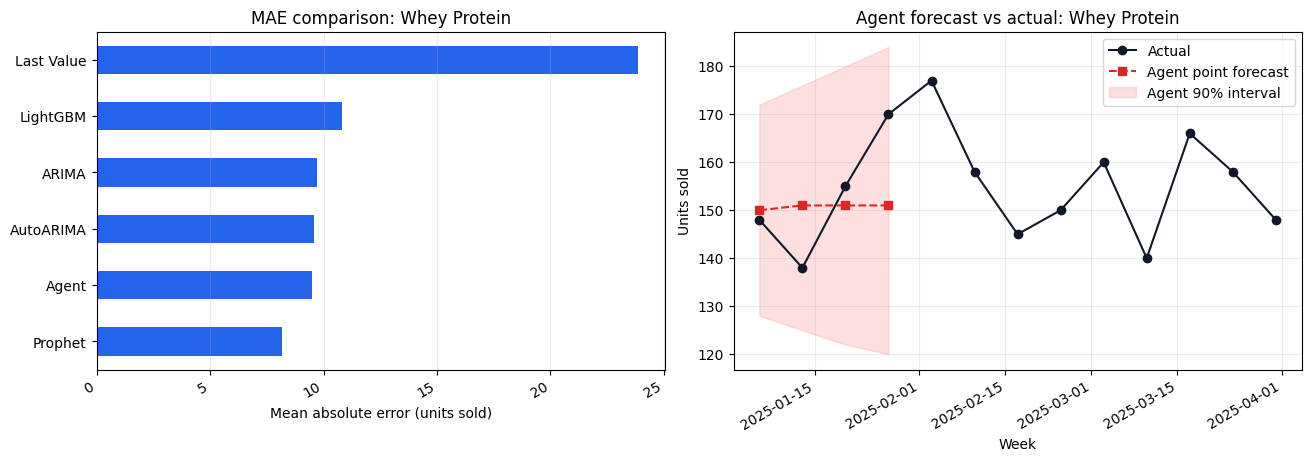

,Actual,Point forecast,P05,P50,P95
Date,,,,,
2025-01-06,148.000,150.000,128.000,150.000,172.000
2025-01-13,138.000,151.000,125.000,151.000,176.000
2025-01-20,155.000,151.000,122.000,151.000,180.000
2025-01-27,170.000,151.000,120.000,151.000,184.000


Agent CRPS approximation from P05/P50/P95: 9.194 (lower is better)


In [8]:
import matplotlib.pyplot as plt


fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), layout="constrained")

comparison.sort_values("MAE")["MAE"].plot.barh(ax=axes[0], color="#2563eb")
axes[0].set_title(f"MAE comparison: {PRODUCT_NAME}")
axes[0].set_xlabel("Mean absolute error (units sold)")
axes[0].set_ylabel("")
axes[0].grid(axis="x", alpha=0.25)

if agent_forecast_frame.empty:
    axes[1].text(0.5, 0.5, "Set RUN_AGENT=True to plot the agent forecast.", ha="center", va="center")
    axes[1].set_axis_off()
else:
    axes[1].plot(actual.index, actual.values, color="#111827", marker="o", label="Actual")
    axes[1].plot(
        agent_forecast_frame.index,
        agent_forecast_frame["Point forecast"],
        color="#dc2626",
        marker="s",
        linestyle="--",
        label="Agent point forecast",
    )
    axes[1].fill_between(
        agent_forecast_frame.index,
        agent_forecast_frame["P05"],
        agent_forecast_frame["P95"],
        color="#fca5a5",
        alpha=0.35,
        label="Agent 90% interval",
    )
    axes[1].set_title(f"Agent forecast vs actual: {PRODUCT_NAME}")
    axes[1].set_xlabel("Week")
    axes[1].set_ylabel("Units sold")
    axes[1].legend()
    axes[1].grid(alpha=0.25)

fig.autofmt_xdate()
plt.show()

if not agent_forecast_frame.empty:
    display(agent_forecast_frame)
    print(f"Agent CRPS approximation from P05/P50/P95: {agent_metrics['CRPS']:.3f} (lower is better)")

## Notes

- Change `PRODUCT_NAME` to forecast another product. The recorded baseline comparison in Section 5 must be refreshed from `01_baseline_models.ipynb` when you change the product.
- Change `TRAIN_END_DATE` to evaluate a different historical origin, then rerun the baseline notebook with the same cutoff before comparing results.
- Section 5 reports MAE, RMSE, MAPE, and sMAPE against the baseline holdout and computes a quantile-based CRPS approximation for the agent when `RUN_AGENT = True`. It also plots the baseline MAE ranking and the agent's forecast interval against actual sales.
- These are single chronological holdout diagnostics, not evidence of calibration or a stable model ranking. Use a rolling-origin `DataService` backtest for a production comparison.
- `RUN_AGENT = False` is intentional: set it to `True` only after reviewing the prompt preview and confirming the proxy credentials are available.
- Search is disabled by default because this task is driven by the supplied sales history. Enable it only when external retail context is part of the forecasting question.